## 기본 함수 삽입

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from sklearn.model_selection import train_test_split
import statsmodels.formula.api as smf
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from datetime import datetime
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
import statsmodels.api as sm
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import os
os.chdir("/home/piai/Desktop/git/2. Big Data 분석")

matplotlib.rc("font", family = "NanumSquare")
matplotlib.rc('axes', unicode_minus=False)

### 데이터 불러오기 및 전처리

In [2]:
df_raw = pd.read_csv("보험료.csv", encoding = "euc-kr")

df_raw['가입유형'].fillna(df_raw['가입유형'].mode()[0], inplace = True)
df_raw['납부유형'].fillna(df_raw['납부유형'].mode()[0], inplace = True)

df_raw = df_raw.drop(['고객번호'], axis = 1)

df_raw_dummy = pd.get_dummies(df_raw, drop_first = True)
df_raw_dummy.head()

df_raw_y = df_raw_dummy["보험료"]
df_raw_x = df_raw_dummy.drop("보험료", axis = 1, inplace = False)

df_train, df_test = train_test_split(df_raw_dummy, test_size = 0.3, random_state = 1234)
df_train_x, df_test_x, df_train_y, df_test_y = train_test_split(df_raw_x, df_raw_y
                                                                , test_size = 0.3, random_state = 1234)

### 이전 과제간 수립한 모델 등록

In [3]:
lr_model = smf.ols(formula = "보험료 ~ BMI + 흡연여부 + 보장범위 + 납입기간", data = df_train)
lr_result = lr_model.fit()

# Decision Tree
dt_model = DecisionTreeRegressor(random_state=1234, min_samples_leaf = 4, min_samples_split = 13, max_depth = 9 )
dt_model.fit(df_train_x, df_train_y)

# Random Forest
rf_model = RandomForestRegressor(random_state=1234, n_estimators = 6, min_samples_leaf = 1,
                                 min_samples_split = 2, max_depth = 6)
rf_model.fit(df_train_x, df_train_y)

# Gradient Boosting
gb_model = GradientBoostingRegressor(random_state=1234, n_estimators = 75, min_samples_leaf = 12, 
                                     min_samples_split = 92, max_depth = 5, learning_rate = 0.4)
gb_model.fit(df_train_x, df_train_y)

GradientBoostingRegressor(learning_rate=0.4, max_depth=5, min_samples_leaf=12,
                          min_samples_split=92, n_estimators=75,
                          random_state=1234)

In [4]:
models = ["회귀분석", "의사결정나무", "랜덤 포레스트", "그래디언트 부스팅"]
mse, rmse, mae, mape = [],[],[],[]

# 회귀분석
lr_y_pred = lr_result.predict(df_test)

mse.append(mean_squared_error(df_test['보험료'], lr_y_pred))
rmse.append(mean_squared_error(df_test_y, lr_y_pred, squared=False))
mae.append(mean_absolute_error(df_test['보험료'], lr_y_pred))
mape.append(mean_absolute_percentage_error(df_test['보험료'], lr_y_pred))

# 의사결정나무
dt_y_pred = dt_model.predict(df_test_x)

mse.append(mean_squared_error(df_test_y, dt_y_pred))
rmse.append(mean_squared_error(df_test_y, dt_y_pred, squared=False))
mae.append(mean_absolute_error(df_test_y, dt_y_pred))
mape.append(mean_absolute_percentage_error(df_test_y, dt_y_pred))

# 랜덤포레스트
rf_y_pred = rf_model.predict(df_test_x)

mse.append(mean_squared_error(df_test_y, rf_y_pred))
rmse.append(mean_squared_error(df_test_y, rf_y_pred, squared=False))
mae.append(mean_absolute_error(df_test_y, rf_y_pred))
mape.append(mean_absolute_percentage_error(df_test_y, rf_y_pred))

# 그래디언트부스팀예측
gb_y_pred = gb_model.predict(df_test_x)

mse.append(mean_squared_error(df_test_y, gb_y_pred))
rmse.append(mean_squared_error(df_test_y, gb_y_pred, squared=False))
mae.append(mean_absolute_error(df_test_y, gb_y_pred))
mape.append(mean_absolute_percentage_error(df_test_y, gb_y_pred))

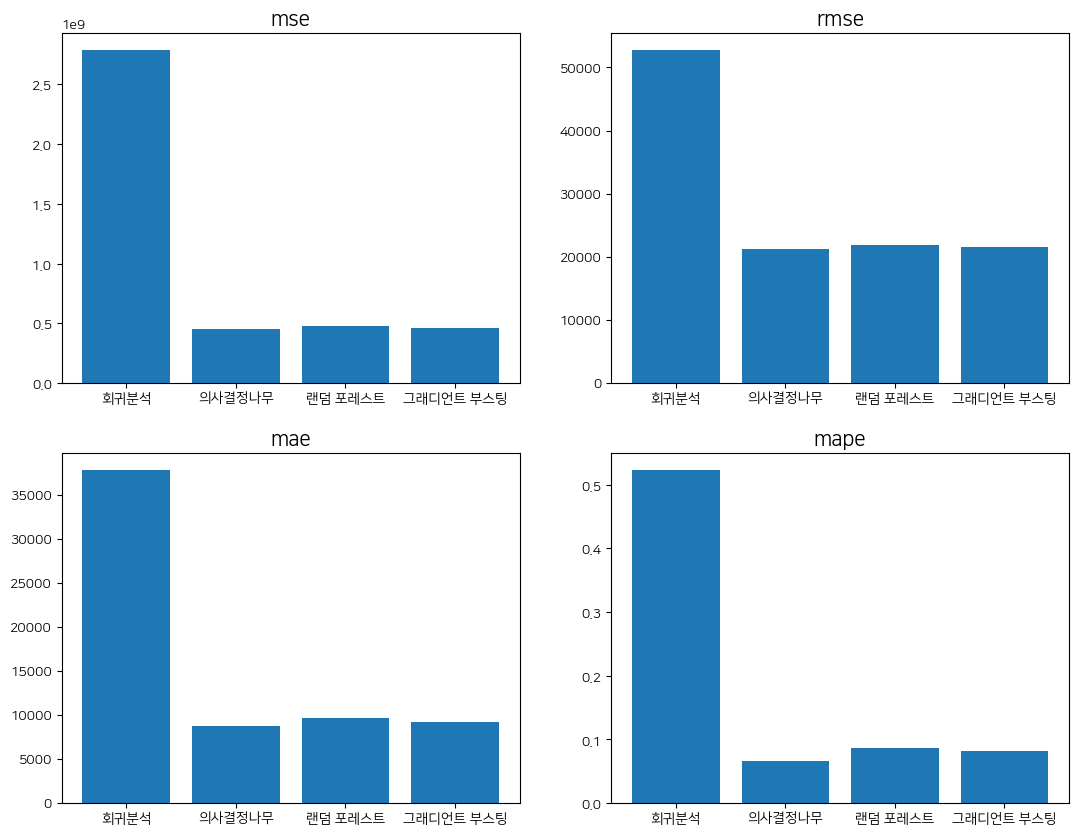

In [5]:
fig, ax = plt.subplots(2,2, figsize = (13,10))
ax[0, 0].bar(models, mse)
ax[0, 0].set_title("mse").set_fontsize(15)

ax[0, 1].bar(models, rmse)
ax[0, 1].set_title("rmse").set_fontsize(15)

ax[1, 0].bar(models, mae)
ax[1, 0].set_title("mae").set_fontsize(15)

ax[1, 1].bar(models, mape)
ax[1, 1].set_title("mape").set_fontsize(15)

회귀분석은 모든 지표에서 오차가 가장 커서 성능이 가장 낮다는 것을 알 수 있었다.<br>
반면, 의사결정나무, 랜덤 포레스트, 그래디언트 부스팅은 모두 유사한 수준의 낮은 오차를 보였다.<br>
회귀분석의 경우 비선형 관계를 잘 반영하지 못해 부정확한 것으로 나타냈지만, 트리 기반 모델들은 데이터의 복잡한 패턴을 잘 학습해 정확도가 높았다.<br>
결론적으로 그래디언트 부스팅과 의사결정나무가 대부분의 평가지표에서 오차가 낮아 우수한 모델로 평가할 수 있다.

## 주성분 분석

In [6]:
df_raw = pd.read_csv("IRIS.csv")
df_raw.head()

,SEPAL_LENGTH,SEPAL_WIDTH,PETAL_LENGTH,PETAL_WIDTH,SPECIES
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [7]:
df_raw_x = df_raw.drop("SPECIES",axis=1)
df_raw_y = df_raw["SPECIES"]

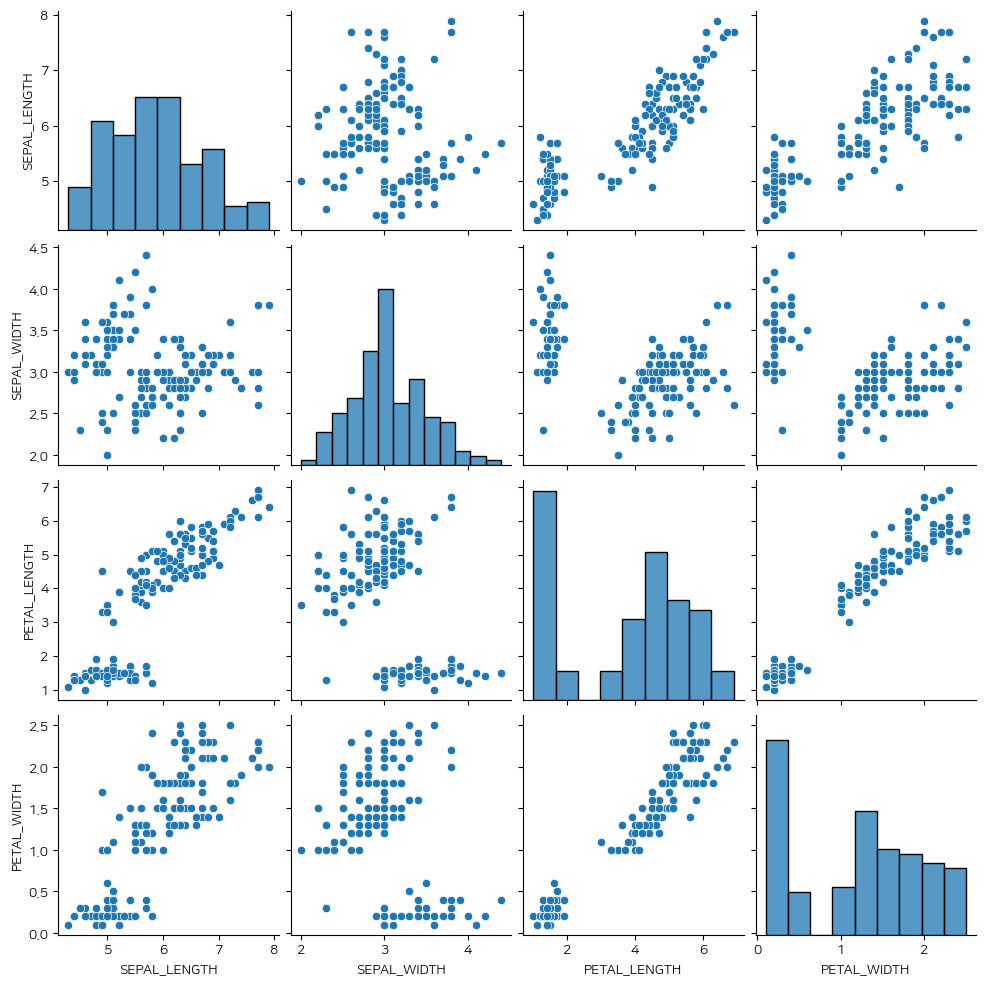

In [8]:
sns.pairplot(df_raw_x)

In [9]:
df_raw_x.corr().round(3)

,SEPAL_LENGTH,SEPAL_WIDTH,PETAL_LENGTH,PETAL_WIDTH
SEPAL_LENGTH,1.000,-0.118,0.872,0.818
SEPAL_WIDTH,-0.118,1.000,-0.428,-0.366
PETAL_LENGTH,0.872,-0.428,1.000,0.963
PETAL_WIDTH,0.818,-0.366,0.963,1.000


In [10]:
df_raw_x.describe().round(3)

,SEPAL_LENGTH,SEPAL_WIDTH,PETAL_LENGTH,PETAL_WIDTH
count,150.000,150.000,150.000,150.000
mean,5.843,3.057,3.758,1.199
std,0.828,0.436,1.765,0.762
min,4.300,2.000,1.000,0.100
25%,5.100,2.800,1.600,0.300
50%,5.800,3.000,4.350,1.300
75%,6.400,3.300,5.100,1.800
max,7.900,4.400,6.900,2.500


### 정규화과정

In [11]:
x_cols = df_raw_x.columns
scaler = StandardScaler()
nd_scaled = scaler.fit_transform(df_raw_x)
print("Scaled Data :\n {}".format(nd_scaled[:5].round(3)))
print("Shape :\n {}".format(nd_scaled.shape))

Scaled Data :
 [[-0.901  1.019 -1.34  -1.315]
 [-1.143 -0.132 -1.34  -1.315]
 [-1.385  0.328 -1.397 -1.315]
 [-1.507  0.098 -1.283 -1.315]
 [-1.022  1.249 -1.34  -1.315]]
Shape :
 (150, 4)


In [12]:
df_scaled = pd.DataFrame(nd_scaled, columns=x_cols ) 
df_scaled.describe().round(3)

,SEPAL_LENGTH,SEPAL_WIDTH,PETAL_LENGTH,PETAL_WIDTH
count,150.000,150.000,150.000,150.000
mean,-0.000,-0.000,-0.000,-0.000
std,1.003,1.003,1.003,1.003
min,-1.870,-2.434,-1.568,-1.447
25%,-0.901,-0.592,-1.227,-1.184
50%,-0.053,-0.132,0.336,0.133
75%,0.675,0.559,0.763,0.791
max,2.492,3.091,1.786,1.712


### 주성분분석

In [13]:
pca = PCA(n_components=4)
nd_pca = pca.fit_transform(df_scaled)
print("PCA Data :\n {}".format(nd_pca[:5]))
print("Shape :\n {}".format(nd_pca.shape))

PCA Data :
 [[-2.26470281  0.4800266  -0.12770602 -0.0241682 ]
 [-2.08096115 -0.67413356 -0.23460885 -0.10300677]
 [-2.36422905 -0.34190802  0.04420148 -0.02837705]
 [-2.29938422 -0.59739451  0.09129011  0.06595556]
 [-2.38984217  0.64683538  0.0157382   0.03592281]]
Shape :
 (150, 4)


In [14]:
df_pca = pd.DataFrame(nd_pca, columns = ["Prin1","Prin2","Prin3","Prin4"])
df_scaled_pca = df_scaled.join(df_pca)
df_scaled_pca.head()

,SEPAL_LENGTH,SEPAL_WIDTH,PETAL_LENGTH,PETAL_WIDTH,Prin1,Prin2,Prin3,Prin4
0,-0.900681,1.019004,-1.340227,-1.315444,-2.264703,0.480027,-0.127706,-0.024168
1,-1.143017,-0.131979,-1.340227,-1.315444,-2.080961,-0.674134,-0.234609,-0.103007
2,-1.385353,0.328414,-1.397064,-1.315444,-2.364229,-0.341908,0.044201,-0.028377
3,-1.506521,0.098217,-1.283389,-1.315444,-2.299384,-0.597395,0.091290,0.065956
4,-1.021849,1.249201,-1.340227,-1.315444,-2.389842,0.646835,0.015738,0.035923


In [15]:
df_pca_stat = pd.DataFrame()
df_pca_stat["PrinNo"] = [i for i in range(1,5)]
df_pca_stat["EigenValues"] = pca.explained_variance_ 
df_pca_stat["EigenValueRatio"] = pca.explained_variance_ratio_ 
df_pca_stat["CumEigenValueRatio"] = np.cumsum(pca.explained_variance_ratio_)
df_pca_stat.round(3)

,PrinNo,EigenValues,EigenValueRatio,CumEigenValueRatio
0,1,2.938,0.730,0.730
1,2,0.920,0.229,0.958
2,3,0.148,0.037,0.995
3,4,0.021,0.005,1.000


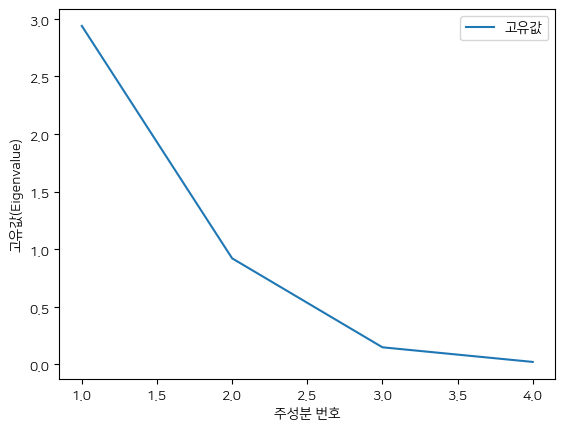

In [16]:
plt.plot(df_pca_stat["PrinNo"], df_pca_stat["EigenValues"], 
         label="고유값")
plt.ylabel("고유값(Eigenvalue)")
plt.xlabel("주성분 번호")
plt.legend(loc="best")
plt.show()

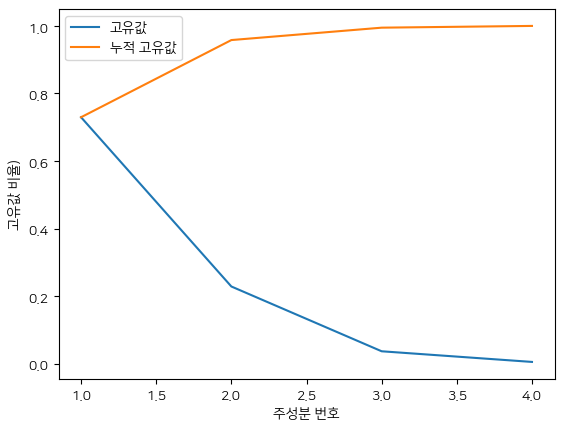

In [17]:
plt.plot(df_pca_stat["PrinNo"], 
         df_pca_stat["EigenValueRatio"], label="고유값")
plt.plot(df_pca_stat["PrinNo"], 
         df_pca_stat["CumEigenValueRatio"], label="누적 고유값")
plt.ylabel("고유값 비율)")
plt.xlabel("주성분 번호")
plt.legend(loc="best")
plt.show()

In [18]:
x_cols = pd.DataFrame({"Feature":df_raw_x.columns})

df_eigenvector = pd.concat([x_cols, pd.DataFrame(pca.components_.T * -1, \
                            columns = ["Prin1","Prin2","Prin3","Prin4"])], axis=1)
df_eigenvector.round(3)

,Feature,Prin1,Prin2,Prin3,Prin4
0,SEPAL_LENGTH,-0.521,-0.377,0.720,0.261
1,SEPAL_WIDTH,0.269,-0.923,-0.244,-0.124
2,PETAL_LENGTH,-0.580,-0.024,-0.142,-0.801
3,PETAL_WIDTH,-0.565,-0.067,-0.634,0.524


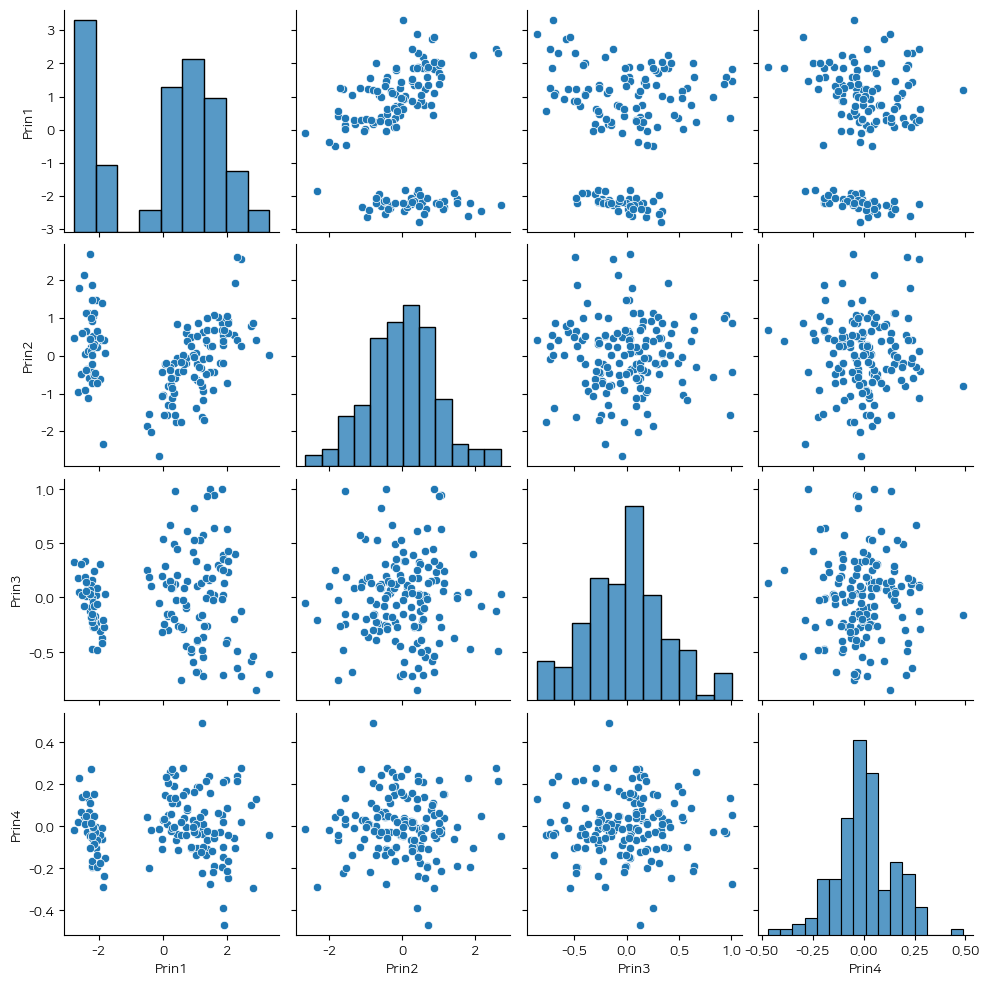

In [19]:
sns.pairplot(df_pca)

In [20]:
df_pca.corr().round(3)

,Prin1,Prin2,Prin3,Prin4
Prin1,1.0,0.0,0.0,-0.0
Prin2,0.0,1.0,-0.0,-0.0
Prin3,0.0,-0.0,1.0,-0.0
Prin4,-0.0,-0.0,-0.0,1.0


주성분분석 결과, 첫 번째 주성분이 전체 분산의 약 73%를 설명하며, 가장 큰 영향을 미친다.<br>
두 번째 주성분은 약 23%를 추가로 설명하며 두가지 요소의 누적 설명력이 약 96%에 달한다.<br>
결론적으로 두 개의 주성분만으로도 대부분의 정보를 설명할 수 있다.<br>
산점도 행렬에서 또한 Prin1과 Prin2가 뚜렷한 분산 패턴을 보이며 주요 차원을 형성하는 것을 알 수 있다.<br>
반면 Prin3, Prin4는 분산이 작고 정보량이 적어 차원 축소 시 제외해도 무방하다.

## 시계열 분석

In [21]:
df_raw = pd.read_csv("환율.csv", parse_dates = ["APPL_DATE"])
df_raw.head()

,CURRENCY,APPL_DATE,STD_RATE,USD_CONV_DATE
0,CNY,2016-01-01,181.48,0.1541
1,JPY,2016-01-01,976.99,0.8294
2,USD,2016-01-01,1178.00,1.0000
3,CNY,2016-01-02,181.48,0.1541
4,JPY,2016-01-02,976.99,0.8294


In [22]:
df_USD = df_raw[df_raw["CURRENCY"] == "USD"].set_index("APPL_DATE")
df_USD.drop(["CURRENCY", "USD_CONV_DATE"], axis = 1, inplace = True)
df_USD.head()

,STD_RATE
APPL_DATE,
2016-01-01,1178.0
2016-01-02,1178.0
2016-01-03,1178.0
2016-01-04,1184.0
2016-01-05,1185.0


In [23]:
train_size = 0.9
len_idx = len(df_USD.index)

mask = (np.arange(len_idx) / len_idx) < train_size
df_USD_train = df_USD[mask]
df_USD_test = df_USD[~mask]
print("shape of train data: {}".format(df_USD_train.shape))
print("shape of test data: {}".format(df_USD_test.shape))

shape of train data: (82, 1)
shape of test data: (9, 1)


In [24]:
df_USD_train = df_USD[df_USD.index <= "2016-03-22"]
df_USD_test = df_USD[df_USD.index > "2016-03-22"]
df_USD_test.head()

,STD_RATE
APPL_DATE,
2016-03-23,1161.0
2016-03-24,1165.0
2016-03-25,1169.0
2016-03-26,1169.0
2016-03-27,1169.0


### 차분

In [ ]:
df_USD_diff1 = df_USD_train - df_USD_train.shift(1)
df_USD_diff1.plot()

<Axes: xlabel='APPL_DATE'>

In [ ]:
df_USD_diff2 = df_USD_train - 2 * (df_USD_train.shift(1)) + (df_USD_train.shift(2))
df_USD_diff2.plot()

2차에 걸친 차분 이후 비로소 데이터가 정상성을 만족하였다.

In [ ]:
lag_size = 30
fig = plt.figure(figsize=(12,8))

ax1 = fig.add_subplot(211)
fig = plot_acf(df_USD_train, lags=lag_size, ax=ax1)

ax2 = fig.add_subplot(212)
fig = plot_pacf(df_USD_train, lags=lag_size, ax=ax2)

In [ ]:
ts_model_usd = ARIMA(df_USD_train, order = (1, 2, 0))

ts_result_usd = ts_model_usd.fit()
print(ts_result_usd.summary())

In [ ]:
start_time = df_USD_test.index.min()
end_time = df_USD_test.index.max()
fig, ax = plt.subplots(figsize = (10, 5))

ax = df_USD_train.plot(ax = ax)
fig = ts_result_usd.predict(start=start_time, end=end_time, ax = ax, plot_insample=False).plot()

In [ ]:
start_time = pd.to_datetime("2016-01-03")
y_pred = ts_result_usd.predict(start=start_time, end=end_time, typ= 'levels')

df_merge = df_USD
df_merge["예측값"]=y_pred
df_merge.plot( y=["STD_RATE","예측값"], figsize=(10,5))

In [ ]:
ts_model = auto_arima(df_USD_train, max_p=3, max_q=3, d=2, 
                      trace=True, error_action='ignore')

In [ ]:
ts_model_usd = ARIMA(df_USD_train, order = (0, 2, 1))

ts_result_usd = ts_model_usd.fit()
print(ts_result_usd.summary())

In [ ]:
start_time = df_USD_test.index.min()
end_time = df_USD_test.index.max()
fig, ax = plt.subplots(figsize = (10, 5))

ax = df_USD_train.plot(ax = ax)

fig = ts_result_usd.predict(start=start_time, end=end_time, ax = ax, plot_insample=False).plot()

In [ ]:
start_time = pd.to_datetime("2016-01-03")
y_pred = ts_result_usd.predict(start=start_time, end=end_time, typ= 'levels')
df_merge = df_USD
df_merge["예측값"]=y_pred
df_merge.head()

In [ ]:
df_merge.plot( y=["STD_RATE","예측값"], figsize=(10, 5))

In [ ]:
ts_model = auto_arima(df_USD_train, max_p = 3, max_q = 3, d = 2, trace = True, error_action = 'ignore')

In [ ]:
ts_model_usd = ARIMA(df_USD_train, order = (0, 2, 1))  # (p,d,q) 지정

ts_result_usd = ts_model_usd.fit()
print(ts_result_usd.summary())

In [ ]:
start_time = df_USD_test.index.min()
end_time = df_USD_test.index.max()

pred = ts_result_usd.get_prediction(start = start_time, end = end_time)
pred_ci = pred.conf_int()
pred_mean = pred.predicted_mean

fig, ax = plt.subplots(figsize = (12,8))
df_USD_train.plot(ax=ax, label = 'STD_RATE')

pred_mean.plot(ax=ax, label = 'forecast', color = 'orange')

ax.fill_between(pred_ci.index, pred_ci.iloc[:,0], pred_ci.iloc[:,1], color = 'gray', alpha = 0.3, label = '95% confidence interval')

ax.set_title("예측값 및 신뢰구간")
ax.set_xlabel('APPL_DATE') ; ax.set_ylabel('STD_RATE')
ax.legend()
plt.show()      

수동 ARIMA(1,2,0)모델보다 자동 ARIMA(0,2,1) 모델의 AIC·BIC가 더 낮아 적합도가 우수하다는 결론이 나왔다.<br>
MA계수는 유의수준 0.001 이하로 통계적으로 유의하였으며, 모델이 잘 추정되었다는 것을 알 수 있다.<br>
미래 데이터 예측 결과, 실제값과 예측값의 추세가 거의 일치하여 모델의 정확도를 알 수 있었다.<br>
결론적으로 앞으로의 달러 환율은 낮아질 것으로 판단되며 수입과 수출에 유의가 필요하다.